### 4. stacking model
##### This model is using emsemble to stack multiple models

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score

In [2]:
# Load the dataset
data = pd.read_csv("../COMP30027_2024_asst2_data/train_dataset_select.csv")
test_data = pd.read_csv("../COMP30027_2024_asst2_data/test_dataset_select.csv")

# Drop the 'id' column as it's just an identifier
data = data.drop(columns=['id'])
test_data = test_data.drop(columns=['id'])

# Split the data into features and target
X = data.drop(columns=['imdb_score_binned'])
y = data['imdb_score_binned']

# Splitting the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=715)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# Define the base models
base_models = [
    ('lr', LogisticRegression(random_state=715)),
    ('dt', DecisionTreeClassifier(random_state=715)),
    ('rf', RandomForestClassifier(random_state=715)),
    ('gb', GradientBoostingClassifier(random_state=715))
]

# Meta-learner model
meta_learner = LogisticRegression(random_state=715)

# Stacking ensemble model
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

In [4]:
# Fit the stacking model on the training data
stacking_model.fit(X_train_scaled, y_train)
# Predict on the test set
predictions = stacking_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# Calculate precision and recall
precision = precision_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')

print("Precision:", precision)
print("Recall:", recall)

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/

Accuracy: 0.7054908485856906
Precision: 0.6761079603246313
Recall: 0.7054908485856906
Confusion Matrix:
 [[  0   0   6   0   0]
 [  0   6  47   1   0]
 [  0  11 335  22   0]
 [  0   0  78  72   1]
 [  0   0   0  11  11]]


C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


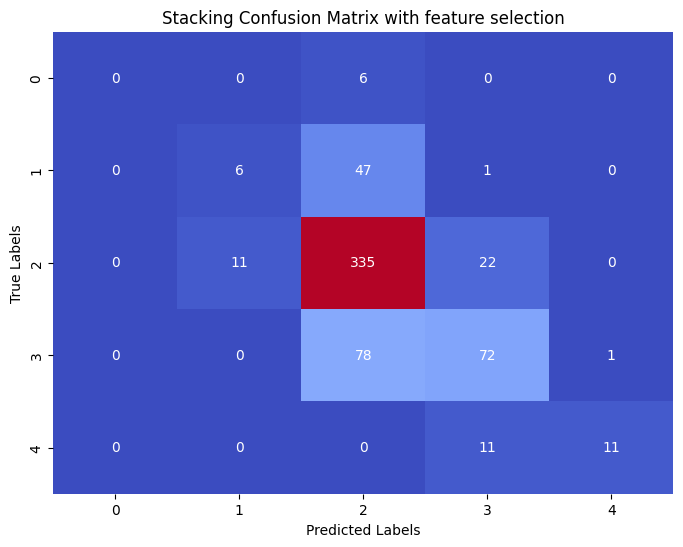

In [5]:
# plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", cbar=False, vmin=0, vmax=cm.max())
plt.title('Stacking Confusion Matrix with feature selection')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig("../COMP30027_2024_asst2_graph/Stacking_Confustion_Matrix_Select.png")
plt.show()

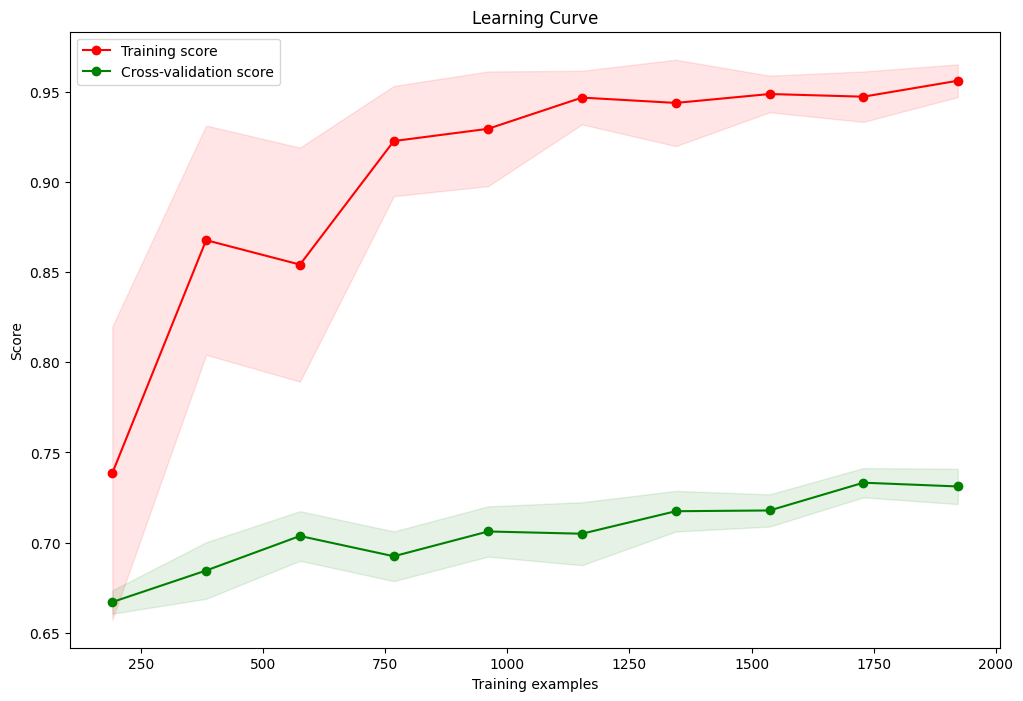

AxisError: axis 1 is out of bounds for array of dimension 1

<Figure size 1000x800 with 0 Axes>

In [17]:
# plot learning curve of stacking model
train_sizes, train_scores, test_scores = learning_curve(stacking_model, X_train_scaled, y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curve of Stacking Model")
plt.legend(loc="best")
plt.savefig("../COMP30027_2024_asst2_graph/Learning_Curve_of_Stacking_Model.png")
plt.show()

Model Overfitting:

The significant gap between the training and cross-validation scores indicates overfitting. The model performs well on the training data but fails to generalize to new, unseen data.
Overfitting could be due to the model being too complex for the available data, capturing noise rather than the underlying data patter
nImprovement with More Data:

The cross-validation score improves as the number of training examples increases. This indicates that the model benefits from additional data and can potentially perform better with more training examples. It suggests that with enough data, the model's performance on unseen data might continue to improve.
zation.

In [ ]:
X_scaled = scaler.fit_transform(X)
test_data_scaled = scaler.transform(test_data)

stacking_model.fit(X_scaled, y)
test_pred = stacking_model.predict(test_data_scaled)

ids = range(1, len(test_pred) + 1)
prediction = pd.DataFrame({'id': ids, 'imdb_score_binned': test_pred})
print(prediction['imdb_score_binned'].value_counts())
prediction.to_csv("../Kaggle_submissions/stacking_model.csv", index=False)